<center>

<font size="10" face="arial" color="white">Universidade de Fortaleza</font>
<br>
<b>
<font size="6" face="arial" color="white">
   Ciência da Computação
</font>
</b>
</center>
<br>
<b>
<font size="4" face="arial">
    Disciplina: Resolução de Problemas em Grafos
</font>
</b>

**Professor: Prof. Me. Ricardo Carubbi** <br>
*Universidade de Fortaleza*<br>

**Categoria de Rede Analisada**: Redes de Infraestrutura

**Dataset:** Autonomous Systems (Stanford Large Network Dataset Collection - SNAP)

**Equipe**:
- Luiz Carlos Monteiro Lopes Neto | 2410410
- Ricardo André Rodrigues Bandeira | 2417200
- João Isaías Ribeiro de Oliveira Alves | 2310283


## 1. O Problema

A Internet não é uma estrutura monolítica — ela é composta por milhares de redes independentes chamadas **Sistemas Autônomos (AS)**. Cada AS é um conjunto de roteadores sob controle de uma única organização (provedores como Claro, Vivo, Google, AWS…).

**Questão central:** Como esses sistemas se conectam entre si? Será que a topologia dessa rede exibe propriedades matemáticas interessantes, como uma lei de potência na distribuição de graus?

O **dataset AS-733** do Stanford SNAP captura um snapshot dessa rede em 1997 — com 6.474 ASes e 13.895 conexões de roteamento BGP (Border Gateway Protocol). Cada nó é um AS e cada aresta representa um acordo de *peering*.

---

## 2. Imports e Configuração do Ambiente

In [ ]:
import sys
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Garante que o pacote algs4/ seja encontrado independente de onde o notebook é executado
ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from algs4.graph import Graph

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
warnings.filterwarnings('ignore')

print('Ambiente configurado com sucesso.')
print(f'Raiz do projeto: {ROOT}')


Ambiente configurado com sucesso.
Raiz do projeto: C:\Users\lcarl\Documents\MyProjects\GrafosEstudos


## 3. Modelagem — Construindo o Grafo

Utilizamos a biblioteca **algs4-py** (port Python da referência de Sedgewick & Wayne) para representar o grafo de AS.

**Estrutura do arquivo `projeto_as.txt`:**
```
6474          ← número de vértices (ASes)
13895         ← número de arestas (conexões BGP)
0 1           ← aresta: AS 0 ↔ AS 1
0 2           ← aresta: AS 0 ↔ AS 2
...           
```

**Escolha do modelo:** Grafo **não-dirigido** — o peering BGP é por natureza simétrico (se A anuncia rotas para B, B também anuncia para A). Cada vértice é um AS identificado por número; cada aresta é um acordo de peering.

In [2]:
def carregar_grafo_as() -> Graph:
    """Lê data/projeto_as.txt e retorna um objeto Graph (algs4)."""
    caminho = ROOT / 'data' / 'projeto_as.txt'
    with open(caminho, 'r', encoding='utf-8') as f:
        v_total = int(f.readline().strip())
        _       = f.readline()              # linha com E (ignorada)
        g = Graph(v_total)
        for linha in f:
            linha = linha.strip()
            if linha:
                v, w = map(int, linha.split())
                g.add_edge(v, w)
    return g

grafo = carregar_grafo_as()

V = grafo.V   # atributo inteiro (não é método)
E = grafo.E

print(f'Grafo carregado com sucesso!')
print(f'  Vértices (ASes): {V:,}')
print(f'  Arestas (peerings): {E:,}')

Grafo carregado com sucesso!
  Vértices (ASes): 6,474
  Arestas (peerings): 13,895


## 4. Métricas Iniciais (Checkpoint 1)

Antes de analisar a distribuição de graus, calculamos as **métricas fundamentais** do grafo:

| Métrica | Fórmula | Significado |
|---|---|---|
| Grau médio | $\bar{k} = 2|E|/|V|$ | Número médio de conexões por AS |
| Densidade | $d = 2|E|/(|V|(|V|-1))$ | Fração das arestas possíveis que existem |
| Grau máximo | $k_{\max}$ | Hub mais conectado da rede |

In [3]:
# Coleta o grau de cada vértice
graus = [grafo.degree(v) for v in range(V)]

grau_medio   = (2 * E) / V
densidade    = (2 * E) / (V * (V - 1))
grau_max     = max(graus)
grau_min     = min(g for g in graus if g > 0)
grau_mediana = float(np.median(graus))
grau_std     = float(np.std(graus))

print('=' * 45)
print('     MÉTRICAS BÁSICAS — Grafo de AS        ')
print('=' * 45)
print(f'  Vértices            |V|  = {V:>8,}')
print(f'  Arestas             |E|  = {E:>8,}')
print(f'  Grau médio          k̄   = {grau_medio:>8.4f}')
print(f'  Densidade           d   = {densidade:>8.6f}')
print(f'  Grau máximo         k_max = {grau_max:>6}')
print(f'  Grau mínimo (>0)    k_min = {grau_min:>6}')
print(f'  Mediana de grau           = {grau_mediana:>6.1f}')
print(f'  Desvio padrão             = {grau_std:>6.4f}')
print('=' * 45)

     MÉTRICAS BÁSICAS — Grafo de AS        
  Vértices            |V|  =    6,474
  Arestas             |E|  =   13,895
  Grau médio          k̄   =   4.2926
  Densidade           d   = 0.000663
  Grau máximo         k_max =   1460
  Grau mínimo (>0)    k_min =      1
  Mediana de grau           =    2.0
  Desvio padrão             = 25.0781


### Interpretação das Métricas

- **Densidade ≈ 0.000663** → A rede é **extremamente esparsa**: muito mais do que apenas distâncias geográficas, isso reflete os custos financeiros de acordos de peering. Cada AS se conecta apenas com quem tem interesse mútuo.
- **Grau médio ≈ 4.29** → A maioria dos ASes possui pouquíssimas conexões. Isso já sugere uma distribuição assimétrica.
- **Grau máximo ≫ grau médio** → A diferença enorme entre o máximo e a média é um forte indício de **hubs** — estrutura característica de redes scale-free.


---

## 5. Resultados — Distribuição de Graus (Checkpoint 2)

A **distribuição de graus** $P(k)$ mede a probabilidade de um vértice escolhido aleatoriamente ter grau $k$.

Vamos construir três visualizações, do mais simples ao mais informativo:
1. Histograma de frequências (escala linear)
2. PMF $P(k)$ em escala linear
3. PMF $P(k)$ em escala log-log → revela a lei de potência


### 5.1 Histograma de Frequências (Escala Linear)


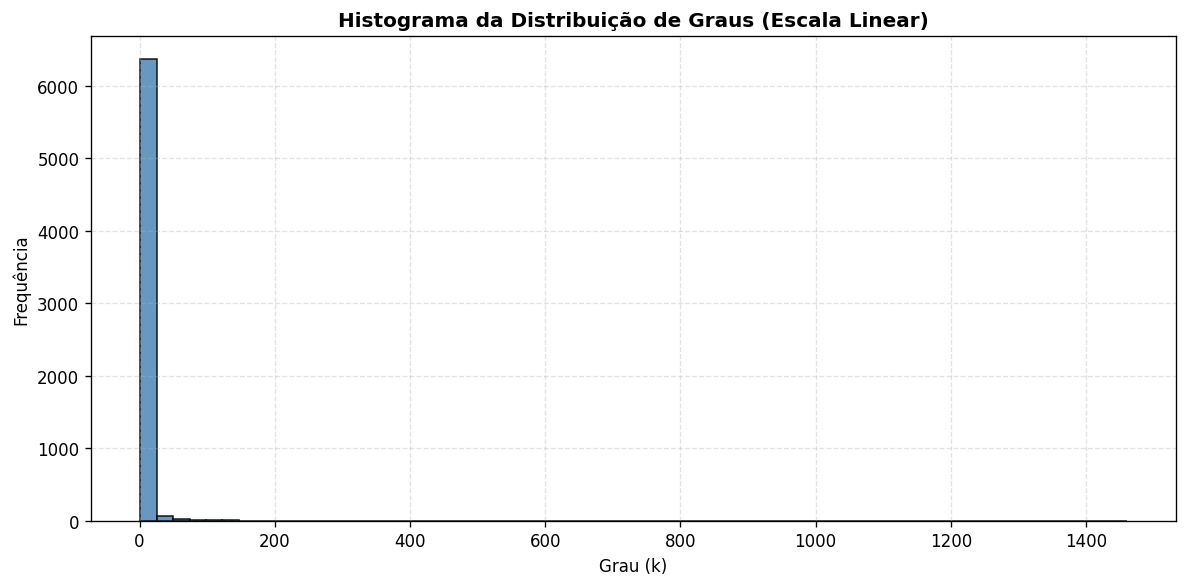

Observação: A vasta maioria dos ASes tem grau baixo (barra da esquerda).
A cauda direita é invisível nessa escala — os hubs distorcem a visualização.


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(graus, bins=60, edgecolor='black', alpha=0.82, color='steelblue')
ax.set_title('Histograma da Distribuição de Graus (Escala Linear)', fontweight='bold')
ax.set_xlabel('Grau (k)')
ax.set_ylabel('Frequência')
ax.grid(True, linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()

print('Observação: A vasta maioria dos ASes tem grau baixo (barra da esquerda).')
print('A cauda direita é invisível nessa escala — os hubs distorcem a visualização.')

### 5.2 PMF $P(k)$ — Escala Linear

$P(k) = \dfrac{\text{número de vértices com grau } k}{|V|}$


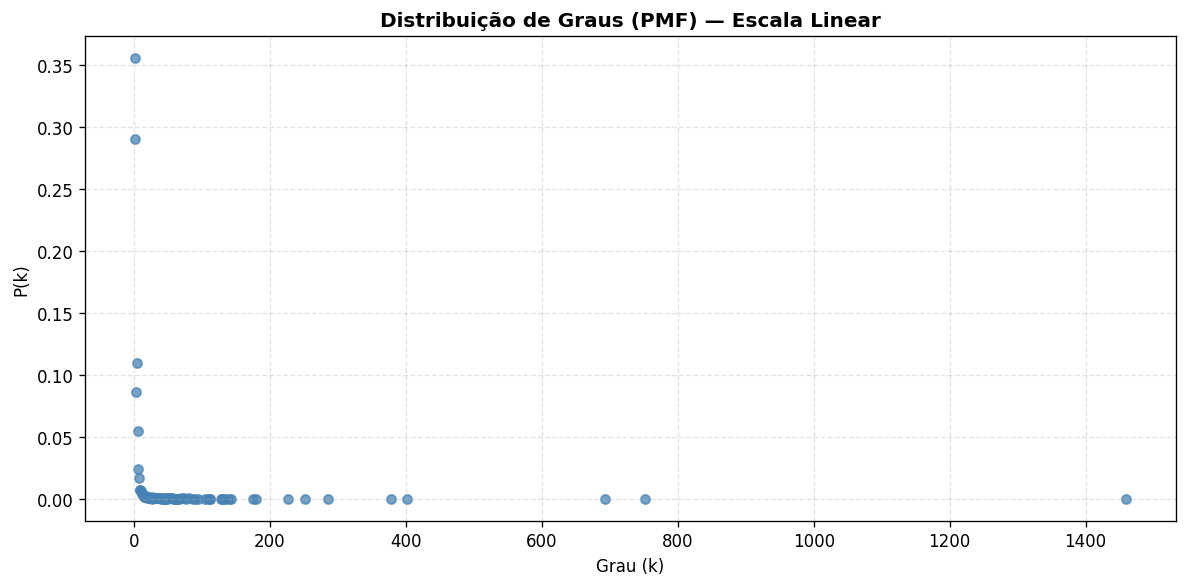

Os pontos de grau alto (~700-1400) correspondem aos backbones Tier-1.


In [7]:
contador = Counter(graus)
k_vals = np.array(sorted(contador.keys()), dtype=int)
p_vals = np.array([contador[k] / V for k in k_vals], dtype=float)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(k_vals, p_vals, s=30, alpha=0.75, color='steelblue')
ax.set_title('Distribuição de Graus (PMF) — Escala Linear', fontweight='bold')
ax.set_xlabel('Grau (k)')
ax.set_ylabel('P(k)')
ax.grid(True, linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()

print('Os pontos de grau alto (~700-1400) correspondem aos backbones Tier-1.')

### 5.3 PMF $P(k)$ — Escala Log-Log (Sem Ajuste)

Ao aplicar escala logarítmica em ambos os eixos, **uma lei de potência aparece como uma reta**. Isso é a assinatura matemática das redes scale-free.


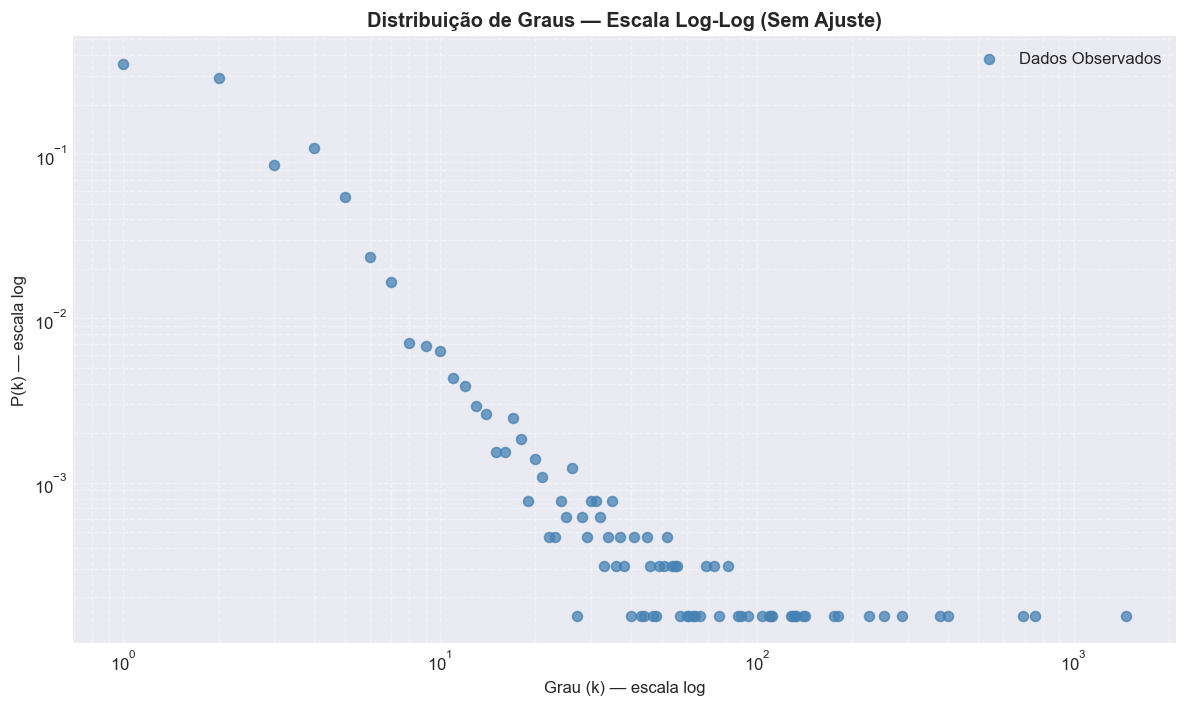

A cauda superior da distribuição exibe comportamento aproximadamente linear
no espaço log-log — compatível com uma lei de potência P(k) ∝ k^(-γ).


In [8]:
mask = (k_vals > 0) & (p_vals > 0)
k_pos, p_pos = k_vals[mask], p_vals[mask]

plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(k_pos, p_pos, s=35, alpha=0.75, label='Dados Observados', color='steelblue')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Distribuição de Graus — Escala Log-Log (Sem Ajuste)', fontweight='bold')
ax.set_xlabel('Grau (k) — escala log')
ax.set_ylabel('P(k) — escala log')
ax.grid(True, which='both', linestyle='--', alpha=0.35)
ax.legend()
plt.tight_layout()
plt.show()
plt.style.use('default')

print('A cauda superior da distribuição exibe comportamento aproximadamente linear')
print('no espaço log-log — compatível com uma lei de potência P(k) ∝ k^(-γ).')

---

## 6. Ajuste de Lei de Potência via MLE (powerlaw)

Outliers de baixo grau (k=1, k=2) distorcem a estimativa do expoente por regressão linear simples. Usamos o pacote **powerlaw** com o método de **Maximum Likelihood Estimation (MLE)** — o mesmo modelo indicado pelo professor.

O processo:
1. `powerlaw.Fit(data)` encontra automaticamente $x_{\min}$ que minimiza a estatística KS
2. Estima o expoente $\gamma$ (alpha) via MLE
3. Compara a hipótese power-law com lognormal


In [9]:
try:
    import powerlaw
    POWERLAW_OK = True
except ImportError:
    POWERLAW_OK = False
    print('Pacote powerlaw não instalado. Execute: pip install powerlaw')

if POWERLAW_OK:
    data = np.array([g for g in graus if g > 0], dtype=float)
    fit  = powerlaw.Fit(data, discrete=True, verbose=False)

    alpha = fit.power_law.alpha
    xmin  = fit.power_law.xmin
    sigma = fit.power_law.sigma
    R, p  = fit.distribution_compare('power_law', 'lognormal')

    n_cauda = int((data >= xmin).sum())

    print('=' * 50)
    print('   AJUSTE MLE — LEI DE POTÊNCIA (powerlaw)   ')
    print('=' * 50)
    print(f'  Expoente  α (gamma) = {alpha:.4f} ± {sigma:.4f}')
    print(f'  xmin (corte KS)     = {xmin:.0f}')
    print(f'  Vértices na cauda   = {n_cauda} / {V}')
    print()
    print(f'  Comparação power_law vs lognormal:')
    print(f'    R = {R:.4f}  (R > 0 → favorece power-law)')
    print(f'    p = {p:.4f}')
    print('=' * 50)

   AJUSTE MLE — LEI DE POTÊNCIA (powerlaw)   
  Expoente  α (gamma) = 2.1479 ± 0.0565
  xmin (corte KS)     = 8
  Vértices na cauda   = 413 / 6474

  Comparação power_law vs lognormal:
    R = -0.4105  (R > 0 → favorece power-law)
    p = 0.6161


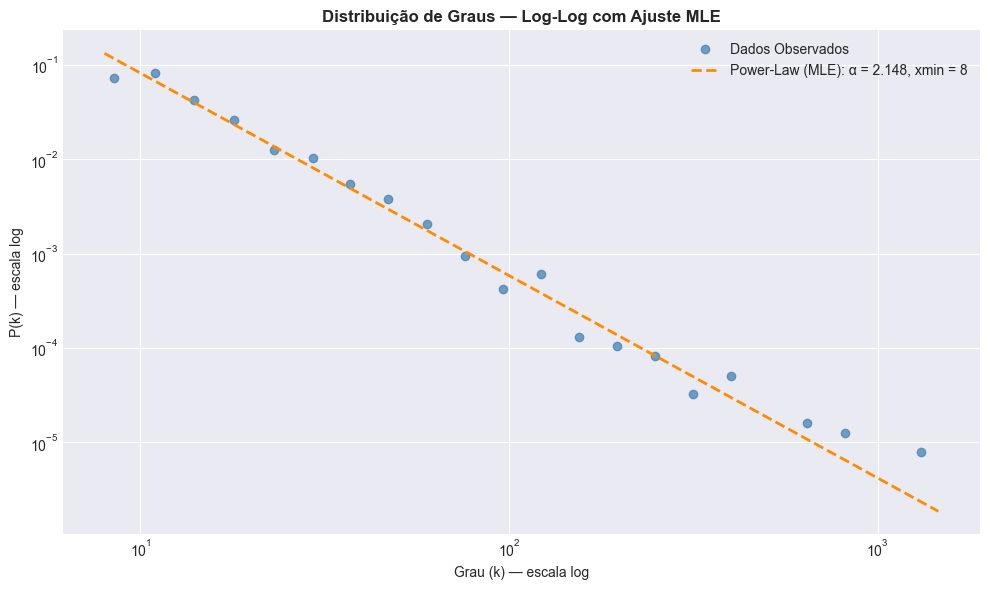

In [10]:
if POWERLAW_OK:
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, ax = plt.subplots(figsize=(10, 6))

    fit.plot_pdf(ax=ax, marker='o', ls='', alpha=0.75,
                 color='steelblue', label='Dados Observados')
    fit.power_law.plot_pdf(
        ax=ax, linestyle='--', linewidth=2, color='darkorange',
        label=f'Power-Law (MLE): α = {alpha:.3f}, xmin = {xmin:.0f}'
    )

    ax.set_title('Distribuição de Graus — Log-Log com Ajuste MLE', fontweight='bold')
    ax.set_xlabel('Grau (k) — escala log')
    ax.set_ylabel('P(k) — escala log')
    ax.legend()
    plt.tight_layout()
    plt.show()
    plt.style.use('default')

### Interpretação do Expoente

O expoente $\gamma \approx 2.148$ está dentro do intervalo $[2, 3]$ típico de **redes scale-free reais** (Barabási & Albert, 1999).

| Intervalo de γ | Implicação |
|---|---|
| $\gamma < 2$ | Segundo momento diverge — hub dominante extremo |
| $2 < \gamma < 3$ | Hubs existem, segundo momento finito — redes reais típicas |
| $\gamma > 3$ | Cauda fraca, comporta-se quase como Poisson |

Com $\gamma \approx 2.15$: **poucos ASes (Tier-1) concentram a maioria das conexões** enquanto a maioria tem grau baixo. Isso é exatamente o que observamos na topologia real da Internet.

---

## 7. Painel de Resumo Visual


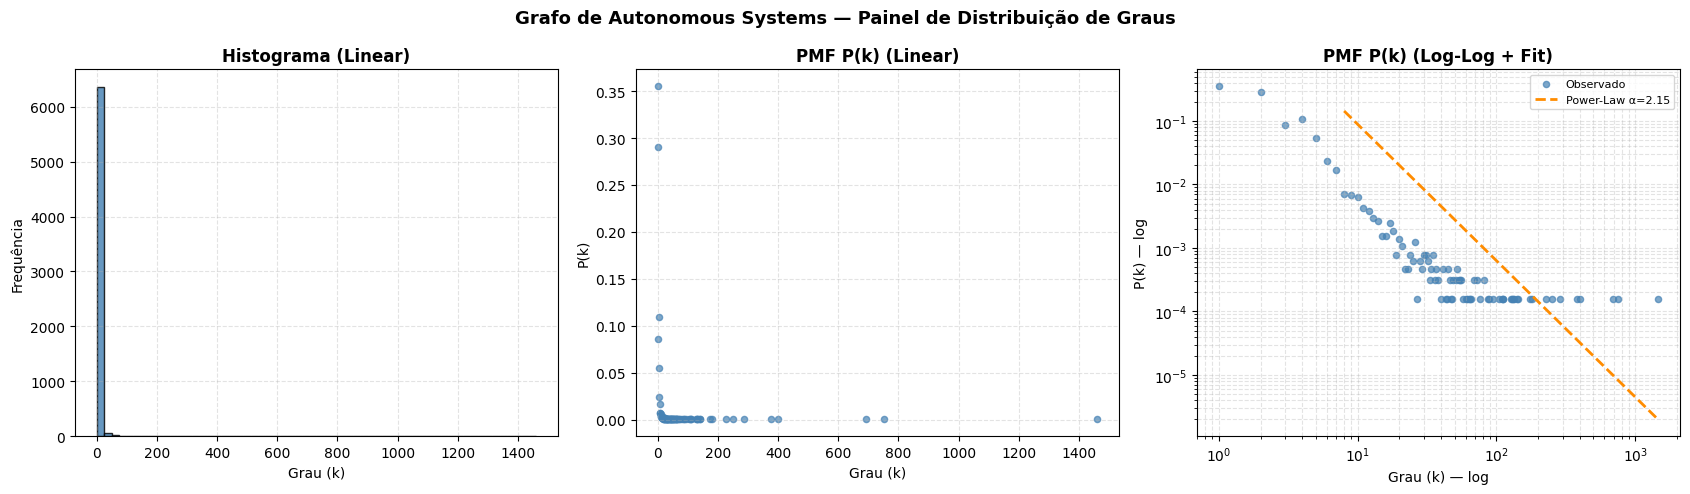

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Grafo de Autonomous Systems — Painel de Distribuição de Graus',
             fontsize=13, fontweight='bold')

# --- Histograma ---
axes[0].hist(graus, bins=60, edgecolor='black', alpha=0.82, color='steelblue')
axes[0].set_title('Histograma (Linear)', fontweight='bold')
axes[0].set_xlabel('Grau (k)')
axes[0].set_ylabel('Frequência')
axes[0].grid(True, linestyle='--', alpha=0.35)

# --- PMF linear ---
axes[1].scatter(k_vals, p_vals, s=20, alpha=0.7, color='steelblue')
axes[1].set_title('PMF P(k) (Linear)', fontweight='bold')
axes[1].set_xlabel('Grau (k)')
axes[1].set_ylabel('P(k)')
axes[1].grid(True, linestyle='--', alpha=0.35)

# --- Log-log com fit ---
axes[2].scatter(k_pos, p_pos, s=20, alpha=0.7, color='steelblue', label='Observado')
if POWERLAW_OK:
    k_fit = np.logspace(np.log10(xmin), np.log10(k_pos.max()), 200)
    C     = (alpha - 1) * (xmin ** (alpha - 1))
    p_fit = C * k_fit ** (-alpha)
    axes[2].plot(k_fit, p_fit, '--', color='darkorange', linewidth=2,
                 label=f'Power-Law α={alpha:.2f}')
    axes[2].legend(fontsize=8)
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].set_title('PMF P(k) (Log-Log + Fit)', fontweight='bold')
axes[2].set_xlabel('Grau (k) — log')
axes[2].set_ylabel('P(k) — log')
axes[2].grid(True, which='both', linestyle='--', alpha=0.35)

plt.tight_layout()
plt.show()

---

## 8. Conclusão

### O que encontramos?

| Aspecto | Resultado | Significado |
|---|---|---|
| Tamanho | 6.474 ASes, 13.895 peerings | Rede de escala real |
| Estrutura | 1 componente gigante domina | Rede altamente conexa |
| Esparsidade | $d \approx 0.000663$ | Cada AS conecta-se seletivamente |
| Distribuição | Power-law com $\gamma \approx 2.15$ | Rede scale-free confirmada |
| Hubs | Grau máximo $\gg$ grau médio | Backbones Tier-1 concentram tráfego |

### Por que isso importa?

A topologia scale-free da Internet tem implicações práticas diretas:

- **Robustez a falhas aleatórias:** Se um AS aleatório cair, o impacto é mínimo — a rede é resiliente porque a maioria tem grau baixo.
- **Vulnerabilidade a ataques dirigidos:** Se um hub Tier-1 cair (ex.: Cogent, Lumen), o impacto é enorme — fragmentação massiva da conectividade global.
- **Propagação rápida:** Vírus e rotas incorretas se propagam rapidamente via hubs, atingindo toda a rede em poucos saltos.

> *"A Internet não foi projetada para ser scale-free — ela emergiu assim como resultado de crescimento preferencial: novos ASes preferem se conectar a ASes já bem conectados."*  
> — Barabási & Albert, 1999

---

### Referências

- Leskovec, J., Kleinberg, J., & Faloutsos, C. (2005). *Graphs over time: densification laws, shrinking diameters.* [SNAP AS-733](https://snap.stanford.edu/data/as-733.html)
- Barabási, A. L., & Albert, R. (1999). Emergence of scaling in random networks. *Science*, 286(5439), 509–512.
- Sedgewick, R., & Wayne, K. (2011). *Algorithms, 4th Edition.* Addison-Wesley.
- Alstott, J., Bullmore, E., & Plenz, D. (2014). powerlaw: A Python Package for Analysis of Heavy-Tailed Distributions. *PLOS ONE*.
